In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df=pd.read_csv("Student Social Media And Mental Health Impact.csv")
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [50]:
df.shape

(5000, 13)

In [51]:
df.isnull().sum().sum()

np.int64(0)

In [52]:
df.duplicated().sum()

np.int64(2)

In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [54]:
df.describe() #min is  in Physical Activity Hours

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


<Axes: xlabel='Mental_Health_Score', ylabel='Count'>

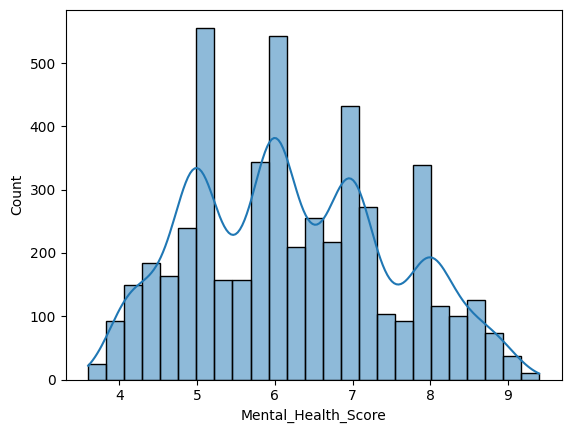

In [55]:
sns.histplot(df['Mental_Health_Score'],kde=True)

<Axes: >

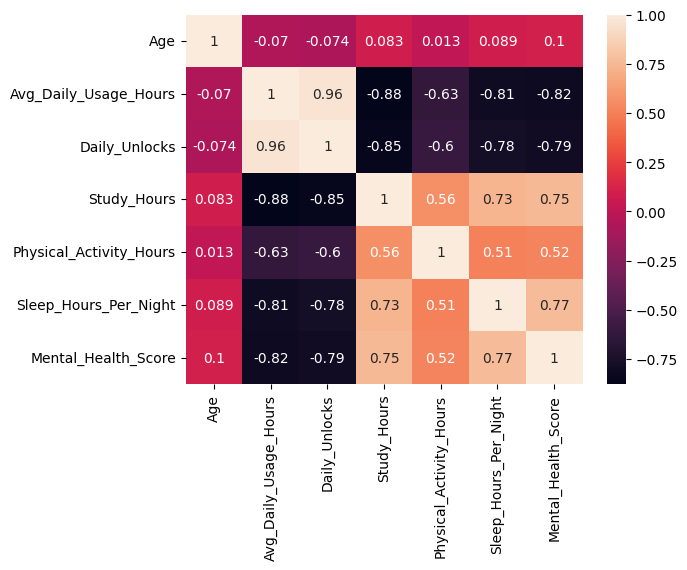

In [56]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [57]:
df['Stress_Level'].unique()

array(['Medium', 'Low', 'Very High', 'High'], dtype=object)

<Axes: xlabel='Stress_Level', ylabel='Mental_Health_Score'>

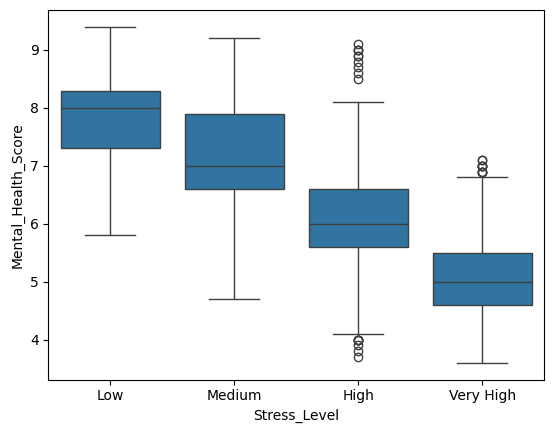

In [58]:
order=['Low','Medium','High','Very High']
sns.boxplot(x='Stress_Level',y='Mental_Health_Score',order=order,data=df)

<Axes: xlabel='Avg_Daily_Usage_Hours', ylabel='Mental_Health_Score'>

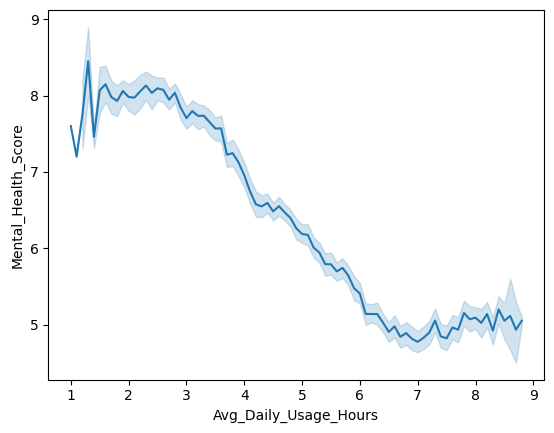

In [59]:
sns.lineplot(x='Avg_Daily_Usage_Hours',y='Mental_Health_Score',data=df)

<Axes: xlabel='Sleep_Hours_Per_Night', ylabel='Mental_Health_Score'>

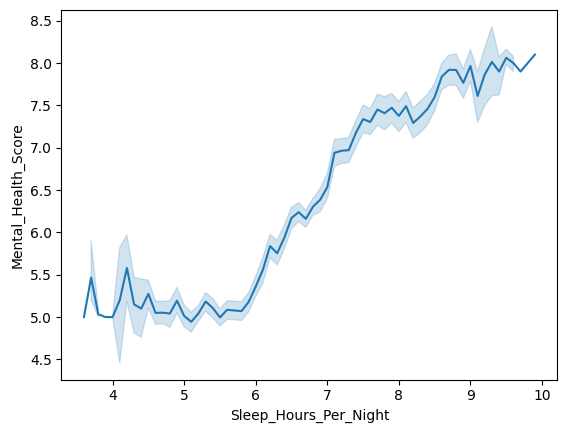

In [60]:
sns.lineplot(x='Sleep_Hours_Per_Night',y='Mental_Health_Score',data=df)

<Axes: xlabel='Most_Used_Platform', ylabel='count'>

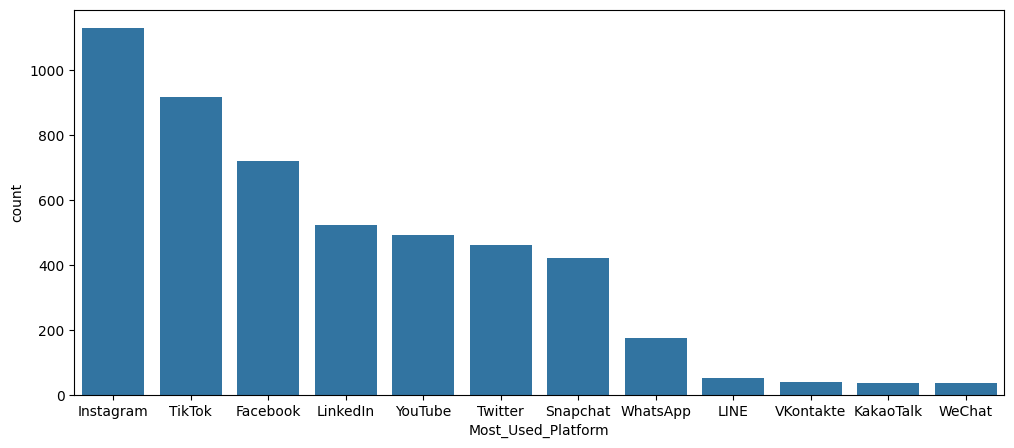

In [61]:
plt.figure(figsize=(12,5))
sns.countplot(x='Most_Used_Platform',data=df,order=df['Most_Used_Platform'].value_counts().index)


In [62]:
num_features=df.select_dtypes(include=['int64','float64'])
q1=num_features.quantile(0.25)
q3=num_features.quantile(0.75)
iqr=q3-q1
lower_bound=q1-(1.5*iqr)
upper_bound=q3+(1.5*iqr)
outliers=(num_features<(lower_bound))|(num_features>(upper_bound))
outliers.sum()

,0
Age,0
Avg_Daily_Usage_Hours,0
Daily_Unlocks,0
Study_Hours,2
Physical_Activity_Hours,22
Sleep_Hours_Per_Night,0
Mental_Health_Score,0


In [63]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [64]:
df['Physical_Activity_Hours']=df['Physical_Activity_Hours'].clip(lower=0) #negative to zero

In [65]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751400,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.667274,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [66]:
df=df.drop_duplicates()

In [67]:
df.duplicated().sum()

np.int64(0)

In [68]:
num_cols=df.select_dtypes(include=['int64','float64'])
num_cols.skew() #near 0-centralized, -ve left, +ve right

,0
Age,0.155008
Avg_Daily_Usage_Hours,0.005575
Daily_Unlocks,0.002309
Study_Hours,0.436125
Physical_Activity_Hours,0.053288
Sleep_Hours_Per_Night,0.123919
Mental_Health_Score,0.207086


In [69]:
top_countries=df['Country'].value_counts().index[:10].tolist()

In [70]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [71]:
df['Grouped_Country']=df['Country'].apply(group_countries)

In [72]:
df['Grouped_Country'].value_counts()

,count
Grouped_Country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [73]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_Country'],
      dtype='object')

In [74]:
from sklearn.model_selection import train_test_split

skewed_col=['Study_Hours']
ordinal_col=['Stress_Level']
other_numeric_col=['Age','Avg_Daily_Usage_Hours', 'Daily_Unlocks', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night']
nominal_col=['Gender','Most_Used_Platform','Grouped_Country','Academic_Level','Purpose_Of_Use']

feature_col=skewed_col+ordinal_col+other_numeric_col+nominal_col
x=df[feature_col]
y=df['Mental_Health_Score']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

In [75]:
df

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score,Grouped_Country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9,Other
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7,Other
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0,India
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7,Other


## **PIPELINE**

In [76]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer,StandardScaler,OrdinalEncoder,OneHotEncoder
from sklearn.compose import ColumnTransformer

In [77]:
#skewed Pipeline

skewed_pipeline=Pipeline(steps=[
  ('log_transform', FunctionTransformer(np.log1p)),
  ('scale',StandardScaler())
])

#Numeric pipeline

plain_numeric_pipeline=Pipeline(steps=[
  ('scale',StandardScaler())
])

#ordinal pipeline

ordinal_pipeline=Pipeline(steps=[
    ('encode',OrdinalEncoder(categories=[['Low','Medium','High','Very High']]))
])

#nominal pipeline

nominal_pipeline=Pipeline(steps=[
    ('encode',OneHotEncoder(handle_unknown='ignore'))
])


column_transformer=ColumnTransformer(transformers=[
    ('skewed',skewed_pipeline,skewed_col),
    ('plain_numeric',plain_numeric_pipeline,other_numeric_col),
    ('ordinal',ordinal_pipeline,ordinal_col),
    ('nominal',nominal_pipeline,nominal_col)
])

In [78]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error

In [79]:
lr_pipeline=Pipeline(steps=[
    ('column_transformer',column_transformer),
    ('regressor',LinearRegression())
])

lr_pipeline.fit(x_train,y_train)
lr_pred=lr_pipeline.predict(x_test)
lr_pred_train=lr_pipeline.predict(x_train)

lr_r2_testing=r2_score(y_test,lr_pred)
lr_r2_training=r2_score(y_train,lr_pred_train)

lr_mae_testing=mean_absolute_error(y_test,lr_pred)


lr_r2_testing,lr_r2_training,lr_mae_testing

(0.739794461743302, 0.7236771199387539, 0.5361775634720183)

In [80]:
from sklearn.ensemble import RandomForestRegressor

In [87]:
rf_pipeline=Pipeline(steps=[
    ('column_transformer',column_transformer),
    ('regressor',RandomForestRegressor(random_state=42))
])

rf_pipeline.fit(x_train,y_train)
rf_pred=rf_pipeline.predict(x_test)
rf_pred_train=rf_pipeline.predict(x_train)

rf_r2_testing=r2_score(y_test,rf_pred)
rf_r2_training=r2_score(y_train,rf_pred_train)

rf_mae_testing=mean_absolute_error(y_test,rf_pred)


rf_r2_testing,rf_r2_training,rf_mae_testing   #better regressor model, accuracy gap so hyperparamter tuning

(0.8773412825296408, 0.9807575517272666, 0.3478153666666668)

## **HYPERPARAMETER TUNING**

In [90]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'regressor__n_estimators'       : [100,200,300],
    'regressor__max_depth'         : [5,10,15],
    'regressor__min_samples_split' : [2,5,10],
    'regressor__min_samples_leaf'  : [1,2,4]
}


random_search=RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter=15,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
    )

random_search.fit(x_train,y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('column_transformer',
                                              ColumnTransformer(transformers=[('skewed',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['Study_Hours']),
                                                                              ('plain_numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['Age',
                                                                                'Avg_Daily_Usage_Hours',
                                                                                'Daily_Unlocks',
                                                                                'Physi...
                                                                                'Most_Used_Platform',
                                                                                'Grouped_Country',
                                                                                'Academic_Level',
                                                                                'Purpose_Of_Use'])])),
                                             ('regressor',
                                              RandomForestRegressor(random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'regressor__max_depth': [5, 10, 15],
                                        'regressor__min_samples_leaf': [1, 2,
                                                                        4],
                                        'regressor__min_samples_split': [2, 5,
                                                                         10],
                                        'regressor__n_estimators': [100, 200,
                                                                    300]},
                   random_state=42, scoring='r2')

In [91]:
random_search.best_params_

{'regressor__n_estimators': 200,
 'regressor__min_samples_split': 5,
 'regressor__min_samples_leaf': 2,
 'regressor__max_depth': 15}

In [94]:
rf_best_pipeline=random_search.best_estimator_
rf_best_pred=rf_best_pipeline.predict(x_test)

r2_score(y_test,rf_best_pred),mean_absolute_error(y_test,rf_best_pred)
#r2 decreases and mae increases so, pre-hyperparameter tuning parameters is used

(0.8649604283846463, 0.36904121734258993)

In [97]:

from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pred))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(x_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(x_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae_testing, rf_mae_testing, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.877341     0.980758  0.347815  0.464150
2    Random Forest (tuned)  0.864960     0.954690  0.369041  0.487012


## **MODEL SAVING**

In [98]:
import joblib
joblib.dump(rf_pipeline,"Mental_Health_Model.pkl")

['Mental_Health_Model.pkl']